# A curious beginner's guide to A/B testing in R

This toolkit contains custom helpers/functionality for A/B testing. It follows the workflow and lays out the basics of the maths behind it. A glossary and a listicle of reference material is included at the bottom.

### Prerequisites

- basic grasp of probability theory and statistics
- fundamentals of R syntax
- curiosity about how things work

### What is A/B testing?

A/B testing is marketing jargon for what the field of statistcs calls hypothesis testing in randomised control trials (RCTs). Those interested in depth and proofs should look to the Reference material section below and chapters on hypothesis testing in particular. I recommend Casella and Berger (2002) and Wackerly et al. (2008), but note that I do so because of my own familiarity with the material rather than the material's superiority. Relevant are also early chapters in both Agresti books (2002, 2019).

### How is A/B testing done?

IN DEVELOPMENT

A/B testing is carried out in the steps outlined in the listicle immediately below. The only exception is data preparation, which should arguably come after we ahve determined the required sample size. I believe it makes sense, however, to get the feel for the data first. The rest of this writeup follows the same workflow .

1. data prep
2. sample size
3. effect size and significance

*See* hypothesis testing in the reference material. 

*See* my [GitHub folder](https://github.com/tros01/notes/tree/main/ab_testing) for a version of this guide scripted in **Python**.

*See* [water challenge notes](https://github.com/tros01/notes/tree/main/water_challenge) and [water challenge project](https://github.com/tros01/projects/tree/main/water_challenge) for a **Bayesian approach** with **Stan**.

In [1]:
# Libraries
library(tidyverse)

# Generation seed
# set.seed(42)

Warning message:
"package 'ggplot2' was built under R version 4.5.2"
── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


## Understand and prepare the data

### What are we up to?

This section should help the reader get familiar with the structure of the data in randomised control trials. We compute the estimates and relate them to the standard confusion matrix. Lastly, we generate some pseudo-random data and organise them in a useful data structure.

### Data presentation and estimates

This guide is not a place to be outlining a [randomised control trial (RCT)](https://en.wikipedia.org/wiki/Randomized_controlled_trial) design. Suffice to say that we have a sample split approximately into two groups of participants ($\text{\{control, treatment\}}$). The sample consists of independent observations. In other words, we *have no* clusters formed either by repeated measures or measures from the same source. An example of a cluster looks, for instance, like [Fisher's tea-tasting experiment](https://en.wikipedia.org/wiki/Lady_tasting_tea), where a single participant generates several observations, which are therefore not independent.

Our data can be represented as a contingency table (count matrix), which tables the counts of individual outcomes,

|   | success | failure | group margin |
| - | ------- | ------- | ------------ | 
| **treatment** | $n_{11}$ | $n_{12}$ | $n_t=n_{11}+n_{12}$ |
| **control** | $n_{21}$ | $n_{22}$ | $n_c=n_{21}+n_{22}$ |
| **outcome margin** | $n_s=n_{11}+n_{21}$ | $n_f=n_{12}+n_{22}$ | $n=n_t+n_c=n_s+n_f$ |

This  allows us to compute per-group estimates. We can derive the estimator formally [(e.g. videos 55-56 of Ben Lambert's course)](https://youtube.com/playlist?list=PLwJRxp3blEvb7P-7po9AxuBwquPv75LjU&si=3rNLPLYJ6lvd_xcU), but, put simply, since we have [binary outcomes (Bernoulli distribution)](https://en.wikipedia.org/wiki/Bernoulli_distribution), per-group estimates are simple proportions $p_{k}=\frac{n_{k1}}{\sum_{j=1}^2 n_{kj}}$ with variance $p_k(1-p_k)$ where $k \in \{ \text{treatment, control} \}$ and $j \in \{ \text{failure, success} \}$. We can be table these in a probability matrix like so,

|   | success | failure | group margin |
| - | ------- | ------- | ------------ | 
| **treatment** | $\hat{p}_1=\frac{n_{11}}{n_t}$ | $1-\hat{p}_1=\frac{n_{12}}{n_t}$ | $\hat{p}_t=1$ |
| **control** | $\hat{p}_2=\frac{n_{21}}{n_c}$ | $1-\hat{p}_2=\frac{n_{22}}{n_c}$ | $\hat{p}_c=1$ |

Allow me to represent the same information in two perhaps more abstract but insightful ways. First, we can understand the groups as the condition and success and failure as the conditional outcomes,

|   | success ($Y=1$) | failure ($Y=0$) | marginal $X$ |
| - | --------------- | --------------- | ------------ |
| **treatment** ($X=1$) | $p_1=P(Y = 1 \mid X = 1)$ | $(1-p_1)=P(Y = 0 \mid X = 1)$ | $P(X=1)=1$ |
| **control** ($X=0$) | $p_2=P(Y = 1 \mid X = 0)$ | $(1-p_2)=P(Y = 0 \mid X = 0)$ | $P(X=0)=1$ |

Second, consider the standard confusion matrix where the actual class is the condition and the predicted class are the outcomes,

|   | predicted positive | predicted negative |   |
| :-: | :----------------: | :----------------: | :-: |
| **actual positive** | True Positive ($TP$)<br>$(1-\alpha)$ | False Negative ($FN$)<br>$P(\text{Type II Error})=\beta$ | Sensitivity<br>$\frac{TP}{TP + FN}$ |
| **actual negative** | False Positive ($FP$)<br>$P(\text{Type I Error})=\alpha$ | True Negative ($TN$)<br>$(1-\beta)$ | Specificity<br>$\frac{TN}{TN + FP}$ |
| | Precision<br>$\frac{TP}{TP + FP}$ | Negative predictive value<br>$\frac{TN}{TN + FN}$ | Accuracy<br>$\frac{TP + TN}{TP + TN + FP + FN}$ |

### Data prep

The code below generates some pseudorandom sample counts from a [uniform distribution](https://www.probabilitycourse.com/chapter4/4_2_1_uniform.php), and computes the per-group probabilities.

Note that if we wanted an equal number of counts in each group, we'd simply set $n_t=n_c$. We could draw $n_{11}$ and $n_{21}$ and work out the complements. Ex.: 
```R
# Generate a balanced sample
    # 200 participants split equally between treatment and control
n <- 200; nt <- n / 2; nc <- nt
    # Construct a dummy matrix
sample <- matrix(0, nrow = 2, ncol = 2)
    # Generate the treatment group counts
sample[1,1] <- floor(runif(1, min = 1, max = nt + 1)); sample[1,2] <- nt - sample[1,1]
    # Generate the control group counts
sample[2,1] <- floor(runif(1, min = 1, max = nc + 1)); sample[2,2] <- nc - sample[2,1]
```

Below we work with a more realistic unbalanced sample.

In [2]:
n <- 200; nt <- n / 2; nc <- nt
n11 <- floor(runif(1, min = 1, max = nt + 1))
n21 <- floor(runif(1, min = 1, max = nc + 1))

df <- tibble(
    group = c("treatment", "control"),
    success = c(n11, n21),
    failure = c(nt - n11, nc - n21)
)

In [3]:
# Extract the data into a matrix
count_mat <- as.matrix(df[,2:ncol(df)])
count_mat

success,failure
26,74
32,68


In [4]:
# Compute the probabilities
prob_mat <- count_mat
prob_mat[1,] <- prob_mat[1,] / sum(prob_mat[1,])
prob_mat[2,] <- prob_mat[2,] / sum(prob_mat[2,])
prob_mat

success,failure
0.26,0.74
0.32,0.68


In [5]:
# Flatten the matrix
count_vec <- as.vector(t(count_mat)) # Transpose to flatten row-wise
count_vec

[1] 26 74 32 68

In [6]:
prob_vec <- as.vector(t(prob_mat))
prob_vec

[1] 0.26 0.74 0.32 0.68

### A graphic intermezzo I

We probably need to communicate our data. Note that in the following pie chart we do not display the conditional probabilities computed above but a joint Bernoulli distribution, which may be more intuitive to grasp. Here, the proportions are therefore computed from the whole rather than from each group, and it is not the probabilities in the rows that add up to 1 but the probabilities in the entire contingency table like so,

|   | success ($Y=1$) | failure ($Y=0$) | marginal $X$ |
| - | --------------- | --------------- | ------------ |
| **treatment** ($X=1$) | $P(Y = 1 \cap X = 1)$ | $P(Y = 0 \cap X = 1)$ | $P(X=1)$ |
| **control** ($X=0$) | $P(Y = 1 \cap X = 0)$ | $P(Y = 0 \cap X = 0)$ | $P(X=0)$ |
| **marginal** $Y$ | $P(Y=1)$ | $P(Y=0)$ | $P(S)=1$ |

In [7]:
gg_df <- df |>
    # Pivot the outcome columns
    pivot_longer(
        cols = -group,
        names_to = "outcome",
        values_to = "proportion"
    ) |>
    mutate(
        # Compute the joint probabilities
        proportion = proportion / sum(proportion),
        # Construct a vector of legend descriptions
        note = case_when(
                # True positives
                group == "treatment" & outcome == "success" ~ paste0(round(proportion * 100, 2), "% had the disease and tested positive."),
                # False negatives
                group == "treatment" & outcome == "failure" ~ paste0(round(proportion * 100, 2), "% had the disease but tested negative."),
                # True negatives
                group == "control" & outcome == "success" ~ paste0(round(proportion * 100, 2), "% were healthy but tested positive."),
                # False positives
                group == "control" & outcome == "failure" ~ paste0(round(proportion * 100, 2), "% were healthy and tested negative.")
            ),
        # Construct a vector of corresponding colours
        colour = c("#8FD694", "#C7A9CF", "#A7C6ED", "#F7A8A6")
    )

gg_df |> print()

# A tibble: 4 × 5
  group     outcome proportion note                                     colour 
  <chr>     <chr>        <dbl> <chr>                                    <chr>  
1 treatment success       0.13 13% had the disease and tested positive. #8FD694
2 treatment failure       0.37 37% had the disease but tested negative. #C7A9CF
3 control   success       0.16 16% were healthy but tested positive.    #A7C6ED
4 control   failure       0.34 34% were healthy and tested negative.    #F7A8A6


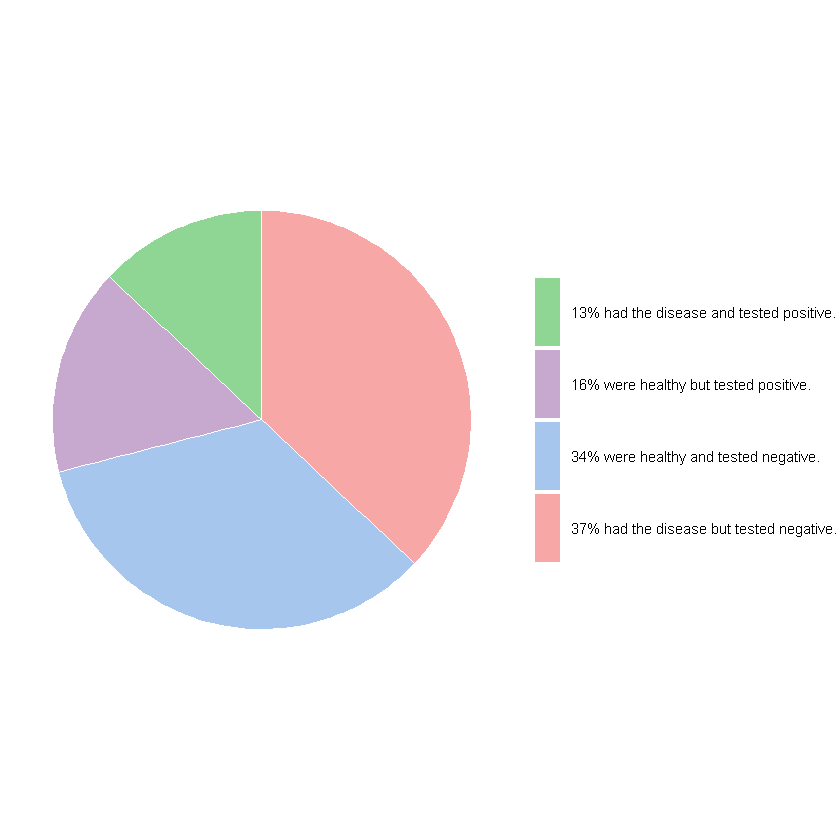

In [8]:
# Pie chart
ggplot(gg_df, aes(x = "", y = proportion, fill = note)) +
    geom_bar(stat = "identity", width = 1, color = "white") +
    coord_polar("y", start = 0) +
    theme_void() +
    theme(
        legend.position   = "right",
        legend.key.height = unit(3, "line")
    ) +
    guides(fill = guide_legend(nrow = 4)) +
    scale_fill_manual(values = gg_df$colour) +
    labs(fill = NULL)

## Sample size

The data section above precedes this one on sample size for the sake of exposition; however, in reality we want to know the sample size before we even start collecting the data.

### What are we up to?

We look at the sample size formula in a modest depth, and then we define a function `sample_size()` that will do the tedious bits for us.

### Operation Treat'n'Convert

We are concerned about finding the sample size $n$ required to achieve a tolerable probability of missing a real effect $\beta$.

$$\begin{align*}
n &= \frac{\left(z_{1-\alpha/2}+z_{1-\beta}\right)^2\sigma^2}{\left(p_0-p_a\right)^2} \\
&= \frac{\left(z_{1-\alpha/2}+z_{1-\beta}\right)^2\sigma^2}{\left(\text{baseline conversion rate}-\text{expected conversion rate}\right)^2}
\end{align*}$$

Note the change in notation from the section on data above. We now have $p_0$ and $p_a$. We do this to distinguish between the data description in the preceding section from the theoretical exercise in this section, where the only empirical input is $p_0$, which is a given proportion we accept as the population parameter. Moreover, we have moved from the world of Bernoulli-distributed outcomes (the underlying distribution) to the world of approximately normally-distributed estimates (the sampling distribution), whence the formula above derived from the [central limit theorem](https://www.probabilitycourse.com/chapter7/7_1_2_central_limit_theorem.php). *See* Wackerly et al. (2008, pp. 507-10) and Casella and Berger (2002, pp. 382-97) you are interested in some depth, else move on to the meat with me.

Let us unpack the formula further and relate it to both statistics and marketing. Let $p_0=\text{baseline conversion rate}$ be the status quo (null hypothesis). This can be $\text{baseline conversion rate}=\frac{\text{current click-through}}{\text{number of website visitors}}$, for instance. Then, $p_a=\text{expected conversion rate}$ is our conversion rate increased by the treatment (alternative hypothesis). To carry on with the example, $\text{expected conversion rate}=\frac{\text{desired click-through}}{\text{number of website visitors}}$. This is the lowest meaningful conversion rate we would like to see. We arrive at it by specifying the $\text{minimum detectable effect (MDE)}=\frac{\text{expected conversion rate} - \text{baseline conversion rate}}{\text{baseline conversion rate}}$, which is the lowest percentage change we care to see in our click-through rate. Then, $\text{expected conversion rate}=\text{baseline conversion rate} \times (1 + \text{MDE})$. This still leaves us with an unexplained and unobserved $\sigma$, which we shall have a look next.

$\sigma$ is an unobserved population standard deviation, which we in practice approximate with the null or alternative model. Let's define a pooled standard deviation $\sigma_0\approx\sqrt{p(1-p)}$ where we in practice choose $p=p_0$. Next, let's define the alternative standard deviation $\sigma_a\approx\sqrt{p_0(1-p_0) + p_a(1-p_a)}$. Plugging this into the formula above, we get,

$$n = \frac{\left( z_{\alpha/2}\sqrt{2p(1-p)} + z_{\beta}\sqrt{p_0(1-p_0) + p_a(1-p_a)} \right)^2}{\left(p_0 - p_a\right)^2}$$

The more concrete notions out of the way, we can now turn to the Greek letters.

### It's all Greek to me



In [9]:
# Parameters
p_0 <- 0.4 # H_0 proportion
p_a <- 0.6 # H_a proportion
n <- 25 # Sample size
alpha <- 0.05 # One-sided significance level

# Standard errors
se_0 <- sqrt(p_0 * (1 - p_0) / n) # Under H_0
se_a <- sqrt(p_a * (1 - p_a) / n) # Under H_a

# Rescale the critical value
z_crit <- qnorm(1 - alpha)
k <- p_0 + z_crit * se_0

# Create data for plotting
x <- seq(0, 1, length.out = 1000)

ggn_df <- tibble(
    x = x,
    phi_0 = dnorm(x, mean = p_0, sd = se_0),
    phi_a = dnorm(x, mean = p_a, sd = se_0)
)

# Pivot to long
ggn_pivoted <- ggn_df |>
    pivot_longer(
        cols = c(phi_0, phi_a),
        names_to = "hypothesis",
        values_to = "density"
    ) |>
    mutate(hypothesis = ifelse(hypothesis == "phi_0", "H_0", "H_a"))

# Shade alpha region (Type I error) under H_0 to the right of k
alpha_region <- ggn_df |>
    filter(x >= k) |>
    select(x, density = phi_0)

# Shade beta region (Type II error) under H_a to the left of k
beta_region <- ggn_df |>
    filter(x <= k) |>
    select(x, density = phi_a)

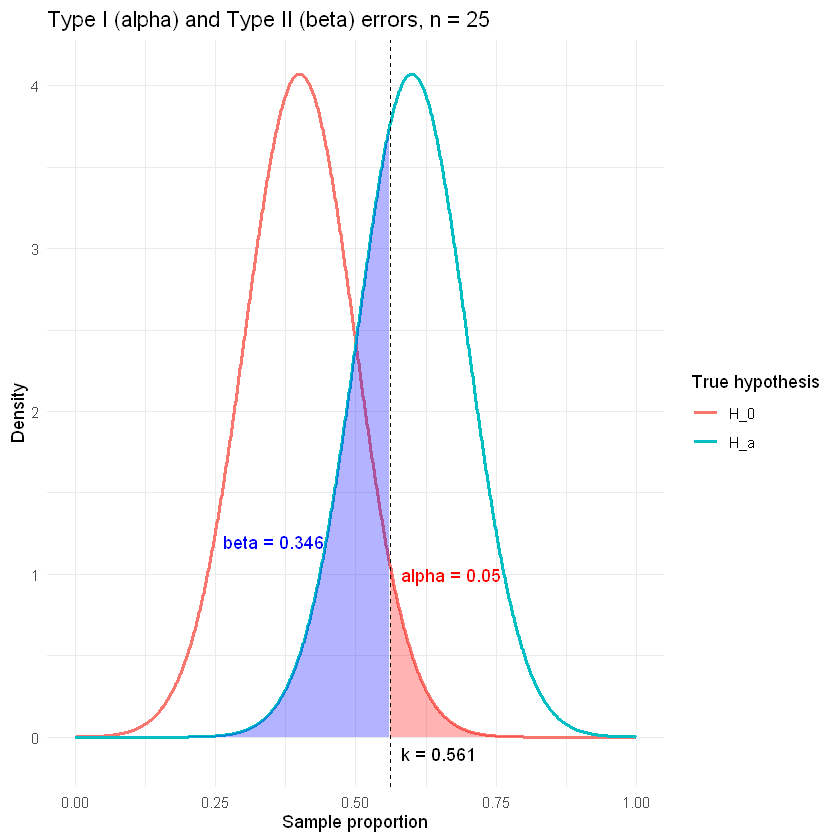

In [10]:
# Plot
ggplot() +
    # Normal curves
    geom_line(
        data = ggn_pivoted,
        aes(x = x, y = density, color = hypothesis),
        linewidth = 1
    ) +
    # Shade alpha (Type I error)
    geom_area(
        data = alpha_region,
        aes(x = x, y = density),
        fill = "red", alpha = 0.3
    ) +
    # Shade beta (Type II error)
    geom_area(
        data = beta_region,
        aes(x = x, y = density),
        fill = "blue", alpha = 0.3
    ) +
    # Critical value line
    geom_vline(xintercept = k, linetype = "dashed", linewidth = 0.2) +
    annotate("text", x = k + 0.02, y = -0.1, 
             label = paste0("k = ", round(k, 3)), hjust = 0) +
    # Add labels for alpha and beta
    annotate("text", x = p_0 + 2.75 * se_0, y = 1, 
             label = paste("alpha =", alpha), color = "red") +
    annotate("text", x = p_a - 2.5 * se_0, y = 1.2, 
             label = paste("beta =", round(pnorm((k - p_a) / se_0), 3)), color = "blue") +
    labs(
        x = "Sample proportion",
        y = "Density",
        color = "True hypothesis",
        title = paste("Type I (alpha) and Type II (beta) errors, n =", n)
    ) +
    theme_minimal() +
    xlim(0, 1)



### The code

In [11]:
# Define the sample_size function
sample_size <- function(p_0, mde=0.1, alpha=0.05, beta=0.2) {

    # The function return the required sample size given the above parameters
    
    power <- 1 - beta
    p_a <- p_0 * (1 + mde)

    z_alpha <- qnorm(1 - alpha / 2)
    z_beta <- qnorm(power)

    var_0 <- p_0 * (1 - p_0)
    var_a <- p_a * (1 - p_a)

    alpha_var <- 2 * var_0
    beta_var <- var_0 + var_a

    alpha_term <- z_alpha * sqrt(alpha_var)
    beta_term <- z_beta * sqrt(beta_var)
    
    effect_size <- p_a - p_0

    n <- ((alpha_term + beta_term)^2) / (effect_size^2)

    return(n)
}

## Testing significance and effect size

### What are we up to?

We are interested in differences between the groups. Namely, we are interested in the estimated **effect size** and the **statistical significance** of the estimate given the assumed null hypothesis and significance level. There are different ways of doing this, each of which has its own merits and demerits we shall leave to more learned literature. Here, we cover the risk difference, the risk ratio and the odds ratio.

### Risk difference

**Risk difference** is a measure of the effect size in terms of the difference between the groups. In brief, 
$$
\begin{align*}
\text{risk difference} &= \text{risk in treatment} - \text{risk in control} \\
\delta &= p_1-p_2 \\
\Rightarrow \hat{\delta} &= \hat{p}_1-\hat{p}_2
\end{align*}
$$

Assume:

- $H_0: \delta = 0$ (i.e. there is no difference between the groups)
- $H_a: \delta \neq 0$ (i.e. this is a two-tailed test where the difference between the groups can be either larger or smaller than 0)
- $\alpha=0.05 \Rightarrow z_{1-\alpha/2} \approx 1.96$ (i.e. 5% of the probability mass falls into the rejection region and this corresponds to the tails 1.96 standard deviations away either side of the mean)

Begin with computing the test statistic, $$z = \frac{\hat{p}_1-\hat{p}_2-\delta}{\sqrt{\hat{p}(1-\hat{p})\left(\frac{1}{n_t}+\frac{1}{n_c}\right)}}, \quad
\hat{p} = \frac{n_{11}}{n_t}+\frac{n_{21}}{n_c}$$

**Decision rule**: We reject $H_0$ if $|z| > z_{1-\alpha/2}$. In this case, the result is said to be statistically significant.

Next, construct the confidence interval, $$\delta \in \hat{p}_1-\hat{p}_2 \pm Z_{1-\alpha} \text{SE}\left(\hat{\delta}\right), \quad
\text{SE}\left(\hat{\delta}\right) = \sqrt{\frac{\hat{p}_1(1-\hat{p}_1)}{n_t} + \frac{\hat{p}_2(1-\hat{p}_2)}{n_c}}$$

**Decision rule**: We reject $H_0$ if $\delta \notin CI_{\delta}$.

In [12]:
#

### Risk ratio

**Risk ratio** measures the effect size as a ratio of the same quantities. In brief,
$$
\begin{align*}
\text{risk ratio} &= \frac{\text{risk in treatment}}{\text{risk in control}} \\
\rho &= \frac{p_1}{p_2} \\
\Rightarrow \hat{\rho} &= \frac{\hat{p}_1}{\hat{p}_2}
\end{align*}
$$

Assume:

- $H_0: \rho = 1$ (i.e. there is no difference between the groups)
- $H_a: \rho \neq 1$ (i.e. this is a two-tailed test where the difference between the groups can be either larger or smaller than 0)
- $\alpha=0.05 \Rightarrow z_{1-\alpha/2} \approx 1.96$

Construct the confidence interval,

$$
\rho \in \exp{\left( \ln{\hat{\rho}}\pm Z_{1-\alpha/2}\sqrt{\widehat{\text{SE}}(\ln{\hat{\rho}})} \right)}, \quad
\widehat{\text{SE}}(\log \hat \rho)
= \sqrt{\frac{1 - \hat p_1}{\hat p_1 n_t} + \frac{1 - \hat p_2}{\hat p_2 n_c}}=\sqrt{\frac{1}{n_{11}} - \frac{1}{n_{11}+n_{12}} + \frac{1}{n_{21}} - \frac{1}{n_{21}+n_{22}}}
$$

Note: Look up the **Haldane-Anscombe correction** if any of the data counts is zero.

**Decision rule**: We reject $H_0$ if $\rho \notin CI_{\rho}$.

In [13]:
#

### Odds ratio

**Odds ratio** measures the effect size as the ratio of the odds. In brief,
$$
\begin{align*}
\text{odds ratio} &= \frac{\text{odds in treatment}}{\text{odds in control}} \\
\theta &= \frac{p_1/(1-p_1)}{p_2/(1-p_2)} \\
\Rightarrow \hat{\theta} &= \frac{\hat{p}_1/(1-\hat{p}_1)}{\hat{p}_2/(1-\hat{p}_2)}
\end{align*}
$$

Assume:

- $H_0: \theta = 1$ (i.e. there is no difference between the groups)
- $H_a: \theta \neq 1$ (i.e. this is a two-tailed test where the difference between the groups can be either larger or smaller than 0)
- $\alpha=0.05 \Rightarrow z_{1-\alpha/2} \approx 1.96$

Construct the confidence interval,

$$
\theta \in \exp{\left( \ln{ \hat \theta \pm Z_{1-\alpha/2}\ \widehat{\mathrm{SE}}(\ln{\hat{\theta}}) } \right)}, \quad
\widehat{\text{SE}}(\ln{\hat{\theta}})
= \sqrt{\frac{1}{n_{11}}+\frac{1}{n_{12}}+\frac{1}{n_{21}}+\frac{1}{n_{22}}}.
$$

Note: Look up the **Haldane-Anscombe correction** if any of the data counts is zero.

**Decision rule**: We reject $H_0$ if $\theta \notin CI_{\theta}$.

In [14]:
#

## Appendix I: Glossary

### alpha / size

The probability of **Type I Error** (reject a true null). Think, "doesn't have the disease, but tested positive anyway". Formally, $$\alpha=P(Y \in \text{rejection region} \mid p=p_{\text{null}})$$

Note that $\alpha$ and $\beta$ are inversely related through the choice of the rejection region. Specify the rejection region as an interval $Y \leq y_{\text{critical}}$ (for a left-tail test) and $Y \geq y_{\text{critical}}$ (for a right-tail test).

### beta

The probability of **Type II Error** (fail to reject a false null). Think, "has the disease, but tested negative nevertheless". Formally, $$\beta=P(Y \notin \text{rejection region} \mid p=p_{\text{alternative}})$$

Specify the rejection region as an interval $Y > y_{\text{critical}}$ (for a left-tail test) and $Y < y_{\text{critical}}$ (for a right-tail test).

### central limit theorem

The result hypothesis testing is built on. In brief, the mean of means converges to the standard normal in distribution as the sample size approaches infinity. For $\text{i.i.d.}$ variables with finite variance, $\frac{\bar{x}-\mu}{\sigma / \sqrt{n}} \overset{d}{\to} \mathcal{N}(0,1)$.

### confidence interval

A range of values, calculated from sample data, that is likely to contain the true value of an unknown population parameter. Note that a frequentist analysis speaks from the perspective of the data. Therefore, a *95% confidence interval will contain the parameter 95% of the time*. (This differs from the Bayesian perspective, which speaks from the perspective of the paramater. Therefore a *95% credible interval implies the posterior probability that the parameter lies within the quantiles given the data*.)

Generally, $\mu \in \bar{x} \pm \text{critical value} \times \text{SE}\left(\bar{x}\right)$.

### critical value

A threshold in statistics that determines whether a test result is statistically significant. This is the bound of the **confidence interval** to be compared with the **test statistic**. 

### decision rule

Reject $H_0$ (the result is significant) if $\text{p-value} < \alpha \Leftrightarrow |\text{test statistic}| > \text{critical value}$. Alternatively, we can compare the null with the confidence interval ($CI$),

### null hypothesis

Status quo. Whatever the researcher decides is to be challenged by the **alternative**. E.g. treatment has no effect, and therefore there is no difference between the two groups.

### p-value

The probability of obtaining results as extreme as, or more extreme than, what was observed in a study, i.e. $P(\text{test statistic at least as extreme as observed} \mid H_0 \text{ true})$. This is the probability mass associated with results falling into the tails of the distribution beyond the normalised value of the test statistic. Think the cumulative probability (tail mass) of the test result being what it is.

The normalised value is a test statistic such as the **z-score** or the **t-statistic**. This is the distance in standard deviations from the mean. The test statistic and the p-value are therefore the obverse of one another.

### power ($1-\beta$)

The probability of correctly rejecting a false null.

### standard error

$\text{SE}\left(\bar{x}\right)=\frac{\hat{\sigma}}{\sqrt{n}}$

### Type I Error

*See* **alpha**.

### Type II Error

*See* **beta**.

### two-tailed test

Compares the **p-value** and the **critical value** on both sides of the distribution. This differs from one-sided variants, the **left-** and the **right-tailed test**. In case of a two-tailed test, **alpha** is split symmetrically across two tails.

## Resources

[Carnes, B. (2024) 'Applied Data Science: A / B Testing'. freeCodeCamp](https://www.freecodecamp.org/news/applied-data-science-a-b-testing/).

[Casalegno, F. (2021) 'A/B Testing – A complete guide to statistical testing'. Towards Data Science](https://towardsdatascience.com/a-b-testing-a-complete-guide-to-statistical-testing-e3f1db140499/).

[Liu, C.H.B., Cardoso, A., Couturier, P. and McCoy, E.J. (2021) 'Datasets for Online Controlled Experiments'](https://datasets-benchmarks-proceedings.neurips.cc/paper_files/paper/2021/file/274ad4786c3abca69fa097b85867d9a4-Paper-round2.pdf).

## Reference material

Agresti, A. (2002) *Categorical Data Analysis*, 2nd edn. Wiley.

Agresti, A. (2019) *An Introduction to Categorical Data Analysis*, 3rd edn. Wiley.

[Ben Lambert](https://www.youtube.com/@SpartacanUsuals). YouTube.

Bickel, J.P. and A.D. Kjell (2015) *Mathematical Statistics: Basic Ideas and Selected Topics, Volume I*, 2nd edn. CRC Press.

Bickel, J.P. and A.D. Kjell (2016) *Mathematical Statistics: Basic Ideas and Selected Topics, Volume II*. CRC Press.

Casella, G. and Berger, R.L. (2002) *Statistical Inference*, 2nd edn. Duxbury.

Hogg, R.V., McKean, J.W. and Craig, A.T. (2020) *Introduction to Mathematical Statistics*, 8th edn. Pearson.

[Pishro-Nik, H. (n.d.) *Introduction to Probability, Statistics and Random Processes*](https://www.probabilitycourse.com/).

[Very Normal](https://www.youtube.com/@very-normal). YouTube.

Wackerly, D.D., Mendenhall, W. and Scheaffer, R.L. (2008) *Mathematical Statistics with Applications*, 7th edn. Thomson.

Wasserman, L. (2004) *All of Statistics: A Concise Course in Statistical Inference*. Springer.